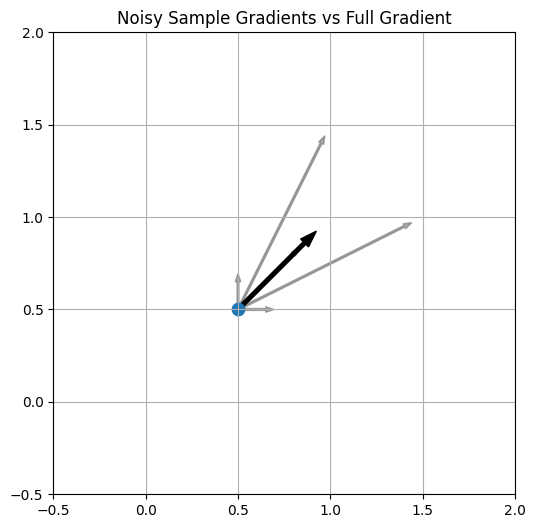

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# current point
x0 = np.array([0.5, 0.5])

# dataset
A = np.array([
    [1,0],
    [0,1],
    [1,1],
    [2,1],
    [1,2]
], dtype=float)

b = np.array([1,1,2,3,3], dtype=float)

# sample gradients
sample_grads = []

for a, bi in zip(A, b):
    g = 2 * (a @ x0 - bi) * a
    sample_grads.append(g)

sample_grads = np.array(sample_grads)

# full gradient
full_grad = sample_grads.mean(axis=0)

# plotting
plt.figure(figsize=(6,6))

# gray sample gradients
for g in sample_grads:
    plt.arrow(
        x0[0], x0[1],
        -0.15*g[0], -0.15*g[1],
        color='gray',
        width=0.01,
        alpha=0.7
    )

# black average gradient
plt.arrow(
    x0[0], x0[1],
    -0.15*full_grad[0],
    -0.15*full_grad[1],
    color='black',
    width=0.02
)

plt.scatter(x0[0], x0[1], s=80)

plt.xlim(-0.5,2.0)
plt.ylim(-0.5,2.0)
plt.grid(True)
plt.gca().set_aspect('equal')

plt.title("Noisy Sample Gradients vs Full Gradient")

plt.savefig("noisy_gradients.png", dpi=300, bbox_inches='tight')
plt.show()

#**데이터 수: 증가**

Normal Equation solution:
theta_0 (intercept) = 1.000000
theta_1 (slope)     = 2.000000


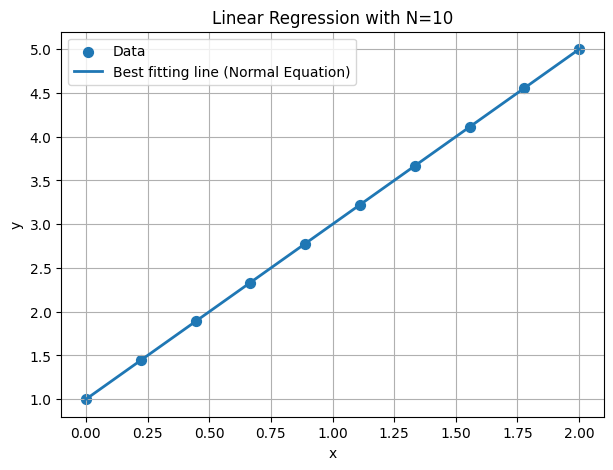


Current theta:
[0.5 0.5]

Sample gradients:
grad_01 = [-1. -0.]
grad_02 = [-1.66666667 -0.37037037]
grad_03 = [-2.33333333 -1.03703704]
grad_04 = [-3. -2.]
grad_05 = [-3.66666667 -3.25925926]
grad_06 = [-4.33333333 -4.81481481]
grad_07 = [-5.         -6.66666667]
grad_08 = [-5.66666667 -8.81481481]
grad_09 = [ -6.33333333 -11.25925926]
grad_10 = [ -7. -14.]

Full gradient (average):
[-4.         -5.22222222]


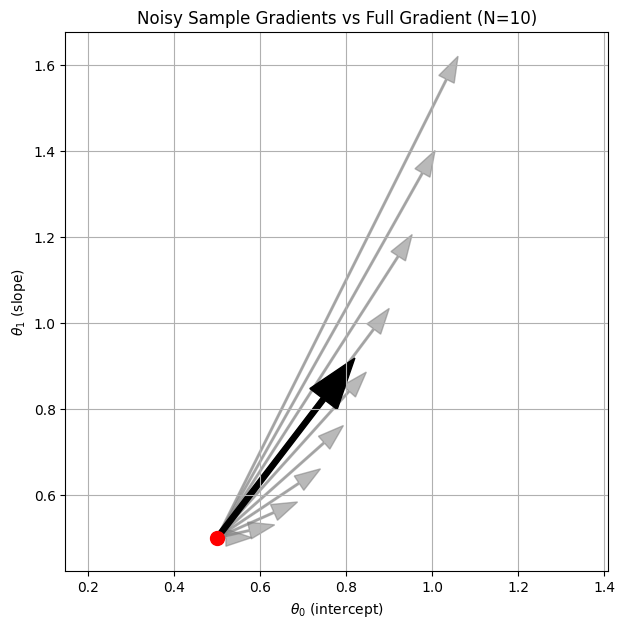

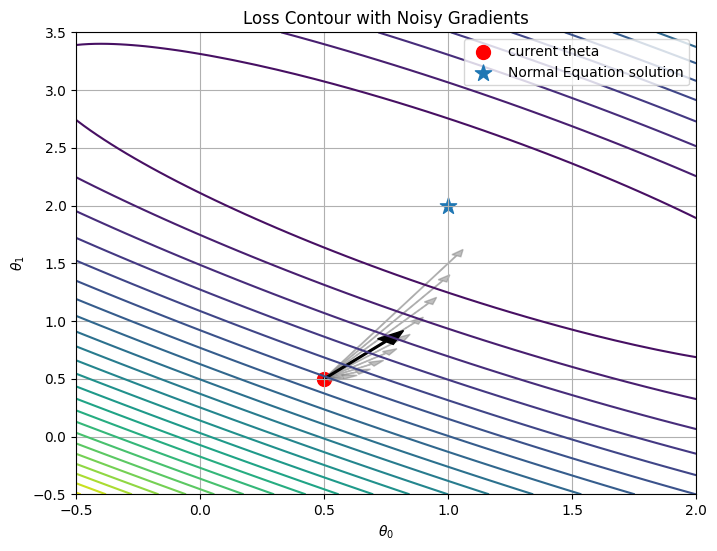

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. 데이터 생성
# ============================================================

np.random.seed(42)

# 데이터 수 선택: 10 또는 20
N = 10   # <-- 10 또는 20으로 변경 가능

x_data = np.linspace(0, 2, N)
#noise = 0.25 * np.random.randn(N)
noise = 0

# true model: y = 1 + 2x + noise
y_data = 1 + 2 * x_data + noise

# Design matrix A = [1, x]
A = np.vstack([np.ones(N), x_data]).T
b = y_data

# ============================================================
# 2. Normal Equation
# ============================================================

theta_ne = np.linalg.solve(A.T @ A, A.T @ b)

print("Normal Equation solution:")
print(f"theta_0 (intercept) = {theta_ne[0]:.6f}")
print(f"theta_1 (slope)     = {theta_ne[1]:.6f}")

# ============================================================
# 3. 데이터 산점도 + best fitting line
# ============================================================

x_plot = np.linspace(x_data.min(), x_data.max(), 200)
y_plot = theta_ne[0] + theta_ne[1] * x_plot

plt.figure(figsize=(7, 5))
plt.scatter(x_data, y_data, label="Data", s=50)
plt.plot(x_plot, y_plot, label="Best fitting line (Normal Equation)", linewidth=2)
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Linear Regression with N={N}")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 4. noisy gradient 시각화를 위한 현재 위치 theta 선택
# ============================================================

# theta = [intercept, slope]
theta_current = np.array([0.5, 0.5])

# sample-wise gradient:
# f_i(theta) = (a_i^T theta - b_i)^2
# grad f_i(theta) = 2 (a_i^T theta - b_i) a_i

sample_grads = []

for i in range(N):
    a_i = A[i]
    b_i = b[i]
    grad_i = 2 * (a_i @ theta_current - b_i) * a_i
    sample_grads.append(grad_i)

sample_grads = np.array(sample_grads)

# full gradient = average of sample gradients
full_grad = sample_grads.mean(axis=0)

print("\nCurrent theta:")
print(theta_current)

print("\nSample gradients:")
for i, g in enumerate(sample_grads):
    print(f"grad_{i+1:02d} = {g}")

print("\nFull gradient (average):")
print(full_grad)

# ============================================================
# 5. noisy gradients 시각화
# ============================================================

plt.figure(figsize=(7, 7))

scale = 0.08

# sample gradients: gray arrows
for g in sample_grads:
    plt.arrow(
        theta_current[0], theta_current[1],
        -scale * g[0], -scale * g[1],
        color="gray",
        alpha=0.55,
        width=0.004,
        head_width=0.04,
        length_includes_head=True
    )

# full gradient: black arrow
plt.arrow(
    theta_current[0], theta_current[1],
    -scale * full_grad[0], -scale * full_grad[1],
    color="black",
    width=0.012,
    head_width=0.08,
    length_includes_head=True,
    label="Full gradient direction"
)

plt.scatter(theta_current[0], theta_current[1], s=100, color="red", zorder=5)

plt.xlabel(r"$\theta_0$ (intercept)")
plt.ylabel(r"$\theta_1$ (slope)")
plt.title(f"Noisy Sample Gradients vs Full Gradient (N={N})")
plt.grid(True)
plt.axis("equal")
plt.show()

# ============================================================
# 6. loss surface contour + noisy gradients
# ============================================================

theta0_grid = np.linspace(-0.5, 2.0, 100)
theta1_grid = np.linspace(-0.5, 3.5, 100)

T0, T1 = np.meshgrid(theta0_grid, theta1_grid)
Z = np.zeros_like(T0)

for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        theta = np.array([T0[i, j], T1[i, j]])
        residual = A @ theta - b
        Z[i, j] = np.mean(residual**2)

plt.figure(figsize=(8, 6))
plt.contour(T0, T1, Z, levels=25)

# current theta
plt.scatter(theta_current[0], theta_current[1], s=100, color="red", label="current theta")

# normal equation solution
plt.scatter(theta_ne[0], theta_ne[1], s=150, marker="*", label="Normal Equation solution")

# sample gradients
for g in sample_grads:
    plt.arrow(
        theta_current[0], theta_current[1],
        -scale * g[0], -scale * g[1],
        color="gray",
        alpha=0.5,
        width=0.003,
        head_width=0.04,
        length_includes_head=True
    )

# full gradient
plt.arrow(
    theta_current[0], theta_current[1],
    -scale * full_grad[0], -scale * full_grad[1],
    color="black",
    width=0.01,
    head_width=0.08,
    length_includes_head=True
)

plt.xlabel(r"$\theta_0$")
plt.ylabel(r"$\theta_1$")
plt.title("Loss Contour with Noisy Gradients")
plt.legend()
plt.grid(True)
plt.show()